# Eksperimen Model Regresi Daya Beli (Model 2)
Notebook ini membandingkan berbagai model Machine Learning (dari Baseline hingga Model Ensemble) untuk memprediksi **Total Pengeluaran per Kapita** (sebagai proksi Daya Beli) per provinsi di Indonesia.

Sesuai instruksi:
- Fitur **TPAK** dan **Pct_Penduduk_Miskin** **dieliminasi** dari pemodelan karena memiliki terlalu banyak *missing values* (masing-masing 38 dan 37 baris kosong).
- Validasi dilakukan secara **Chronological Split** (Train: 2021-2023, Val: 2024, Test: 2025) untuk menghindari data leakage temporal.
- Kita mengimplementasikan beberapa teknik feature engineering tingkat lanjut dan menggunakan model ensambel (XGBoost, LightGBM, CatBoost) untuk memperoleh hasil prediksi yang tangguh.
- Kita menyertakan Uji Multikolinearitas (VIF), Analisis Pengaruh Fitur (Standardized Coefficients), serta Uji Asumsi Klasik Residual (Normalitas & Heteroskedastisitas) lengkap dengan interpretasinya.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 1. Load Data & Analisis Missing Value
Kita load data `clean_daya_beli.csv` yang tersimpan di folder processed.

In [2]:
# Load dataset
data_path = os.path.join('..', 'datasets', 'processed', 'clean_daya_beli.csv')
df = pd.read_csv(data_path)

print("Informasi Dataset Awal:")
print(df.info())
print("\nJumlah Missing Value per Kolom:")
print(df.isnull().sum())


Informasi Dataset Awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Provinsi                   177 non-null    object 
 1   Tahun                      177 non-null    int64  
 2   Pengeluaran_Makanan        177 non-null    float64
 3   Pengeluaran_Bukan_Makanan  177 non-null    float64
 4   Total_Pengeluaran          177 non-null    float64
 5   UMP                        177 non-null    float64
 6   TPT                        177 non-null    float64
 7   TPAK                       139 non-null    float64
 8   PDRB_HargaBerlaku          177 non-null    float64
 9   PDRB_HargaKonstan          177 non-null    float64
 10  Pct_Penduduk_Miskin        140 non-null    float64
 11  Inflasi_Rata_Tahunan       177 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 16.7+ KB
None

Jumlah Missing Va

## 2. Seleksi Fitur & Eliminasi Missing Value
Kita menghapus fitur `TPAK` dan `Pct_Penduduk_Miskin` karena persentase kekosongan data yang tinggi. Fitur target yang diprediksi adalah `Total_Pengeluaran`.

In [3]:
# Drop kolom TPAK dan Pct_Penduduk_Miskin
df_clean = df.drop(columns=['TPAK', 'Pct_Penduduk_Miskin'])

# Pisahkan juga Pengeluaran_Makanan dan Pengeluaran_Bukan_Makanan agar tidak menjadi leakage (karena jumlahnya pasti sama dengan Total_Pengeluaran)
df_clean = df_clean.drop(columns=['Pengeluaran_Makanan', 'Pengeluaran_Bukan_Makanan'])

print("Missing values setelah pembersihan:")
print(df_clean.isnull().sum())
print("\nShape data:", df_clean.shape)
df_clean.head()


Missing values setelah pembersihan:
Provinsi                0
Tahun                   0
Total_Pengeluaran       0
UMP                     0
TPT                     0
PDRB_HargaBerlaku       0
PDRB_HargaKonstan       0
Inflasi_Rata_Tahunan    0
dtype: int64

Shape data: (177, 8)


,Provinsi,Tahun,Total_Pengeluaran,UMP,TPT,PDRB_HargaBerlaku,PDRB_HargaKonstan,Inflasi_Rata_Tahunan
0,Aceh,2021,1137819.32,3165031.0,6.300,34673.56,25356.45,0.155
1,Bali,2021,1468624.11,2494000.0,5.395,50758.32,33123.79,0.155
2,Banten,2021,1511256.67,2460997.0,8.995,55383.29,38339.42,0.155
3,Bengkulu,2021,1138572.40,2215000.0,3.685,39167.13,23545.64,0.155
4,DI Yogyakarta,2021,1417870.35,1765000.0,4.420,40516.00,29115.86,0.155


## 3. Advanced Feature Engineering
Kita membuat fitur-fitur baru yang merepresentasikan rasio ekonomi penting:
1. **GDP Deflator proxy**: `PDRB_HargaBerlaku / PDRB_HargaKonstan` (Menunjukkan tingkat harga kumulatif/inflasi regional).
2. **Real UMP**: `UMP / (1 + Inflasi_Rata_Tahunan)` (Menunjukkan daya beli riil upah minimum terhadap inflasi).
3. **PDRB to UMP ratio**: `PDRB_HargaKonstan / UMP` (Indikator produktivitas regional relatif terhadap standar upah minimum).
4. **TPT x UMP interaction**: `TPT * UMP` (Interaksi antara tingkat pengangguran dengan tingkat upah provinsi).


In [4]:
def engineer_features(data):
    df_feat = data.copy()
    # 1. Rasio PDRB Nominal terhadap Riil (GDP Deflator proxy)
    df_feat['GDP_Deflator'] = df_feat['PDRB_HargaBerlaku'] / df_feat['PDRB_HargaKonstan']
    
    # 2. UMP disesuaikan dengan inflasi
    df_feat['Real_UMP'] = df_feat['UMP'] / (1 + df_feat['Inflasi_Rata_Tahunan'])
    
    # 3. Rasio PDRB Riil terhadap UMP
    df_feat['PDRB_to_UMP'] = df_feat['PDRB_HargaKonstan'] / df_feat['UMP']
    
    # 4. Interaksi Pengangguran dengan UMP
    df_feat['TPT_x_UMP'] = df_feat['TPT'] * df_feat['UMP']
    
    return df_feat

df_engineered = engineer_features(df_clean)
print("Fitur baru berhasil dibuat. Shape baru:", df_engineered.shape)
df_engineered.head()


Fitur baru berhasil dibuat. Shape baru: (177, 12)


,Provinsi,Tahun,Total_Pengeluaran,UMP,TPT,PDRB_HargaBerlaku,PDRB_HargaKonstan,Inflasi_Rata_Tahunan,GDP_Deflator,Real_UMP,PDRB_to_UMP,TPT_x_UMP
0,Aceh,2021,1137819.32,3165031.0,6.300,34673.56,25356.45,0.155,1.367445,2.740287e+06,0.008011,1.993970e+07
1,Bali,2021,1468624.11,2494000.0,5.395,50758.32,33123.79,0.155,1.532383,2.159307e+06,0.013281,1.345513e+07
2,Banten,2021,1511256.67,2460997.0,8.995,55383.29,38339.42,0.155,1.444552,2.130733e+06,0.015579,2.213667e+07
3,Bengkulu,2021,1138572.40,2215000.0,3.685,39167.13,23545.64,0.155,1.663456,1.917749e+06,0.010630,8.162275e+06
4,DI Yogyakarta,2021,1417870.35,1765000.0,4.420,40516.00,29115.86,0.155,1.391544,1.528139e+06,0.016496,7.801300e+06


## 4. Chronological Train-Val-Test Split
Untuk mencegah temporal data leakage (data masa depan memprediksi masa lalu), kita melakukan split secara kronologis berdasarkan kolom `Tahun`:
- **Train Set**: Tahun 2021 - 2023 (Data historis awal)
- **Validation Set**: Tahun 2024 (Untuk tuning model)
- **Test Set**: Tahun 2025 (Data teruji paling akhir)


In [5]:
# Pisahkan X dan y
target_col = 'Total_Pengeluaran'
features_list = [col for col in df_engineered.columns if col not in [target_col]]

train_mask = df_engineered['Tahun'] <= 2023
val_mask = df_engineered['Tahun'] == 2024
test_mask = df_engineered['Tahun'] == 2025

X_train_raw = df_engineered[train_mask][features_list]
y_train = df_engineered[train_mask][target_col]

X_val_raw = df_engineered[val_mask][features_list]
y_val = df_engineered[val_mask][target_col]

X_test_raw = df_engineered[test_mask][features_list]
y_test = df_engineered[test_mask][target_col]

print(f"Train Set Shape : {X_train_raw.shape}, y: {y_train.shape} (Tahun 2021-2023)")
print(f"Val Set Shape   : {X_val_raw.shape}, y: {y_val.shape} (Tahun 2024)")
print(f"Test Set Shape  : {X_test_raw.shape}, y: {y_test.shape} (Tahun 2025)")


Train Set Shape : (102, 11), y: (102,) (Tahun 2021-2023)
Val Set Shape   : (38, 11), y: (38,) (Tahun 2024)
Test Set Shape  : (37, 11), y: (37,) (Tahun 2025)


## 5. Pipeline Preprocessing (Scaling & Encoding)
Kita menggunakan `ColumnTransformer` untuk memproses tipe data berbeda:
- Fitur Numerik: Di-scale menggunakan `StandardScaler`.
- Fitur Kategorikal (`Provinsi`): Di-encode menggunakan `OneHotEncoder` (untuk model linier) atau label encoded untuk tree models.


In [6]:
num_features = ['Tahun', 'UMP', 'TPT', 'PDRB_HargaBerlaku', 'PDRB_HargaKonstan', 
                'Inflasi_Rata_Tahunan', 'GDP_Deflator', 'Real_UMP', 'PDRB_to_UMP', 'TPT_x_UMP']
cat_features = ['Provinsi']

# Pipeline untuk model Linier (butuh OneHotEncoder)
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

# Pipeline untuk model Tree-based (bisa pakai ordinal encoding/label encoding atau OneHot)
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_features)
    ]
)

X_train_lin = preprocessor_linear.fit_transform(X_train_raw)
X_val_lin = preprocessor_linear.transform(X_val_raw)
X_test_lin = preprocessor_linear.transform(X_test_raw)

X_train_tree = preprocessor_tree.fit_transform(X_train_raw)
X_val_tree = preprocessor_tree.transform(X_val_raw)
X_test_tree = preprocessor_tree.transform(X_test_raw)

print("Preprocessed linear shape:", X_train_lin.shape)
print("Preprocessed tree shape:", X_train_tree.shape)


Preprocessed linear shape: (102, 44)
Preprocessed tree shape: (102, 44)


## 6. Model 1: Ridge Regression (Baseline)
Kita menggunakan Ridge Regression (L2 Regularized Linear Regression) sebagai baseline.

In [7]:
# Inisialisasi dan Train Baseline
baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train_lin, y_train)

# Prediksi
y_pred_val_base = baseline_model.predict(X_val_lin)
y_pred_test_base = baseline_model.predict(X_test_lin)

# Evaluasi Test Set
mae_base = mean_absolute_error(y_test, y_pred_test_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_test_base))
r2_base = r2_score(y_test, y_pred_test_base)

print(f"Baseline Ridge -> Test MAE: {mae_base:.2f}, Test RMSE: {rmse_base:.2f}, R2: {r2_base:.4f}")


Baseline Ridge -> Test MAE: 134140.47, Test RMSE: 153777.91, R2: 0.8193


## 7. Model 2: Random Forest Regressor
Model ensemble klasik berbasis Bagging.

In [8]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train_tree, y_train)

y_pred_test_rf = rf_model.predict(X_test_tree)

mae_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
r2_rf = r2_score(y_test, y_pred_test_rf)

print(f"Random Forest -> Test MAE: {mae_rf:.2f}, Test RMSE: {rmse_rf:.2f}, R2: {r2_rf:.4f}")


Random Forest -> Test MAE: 162504.17, Test RMSE: 212806.99, R2: 0.6540


## 8. Model 3: XGBoost Regressor
Model Gradient Boosting terkenal yang sangat kuat untuk data tabular.

In [9]:
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train_tree, y_train)

y_pred_test_xgb = xgb_model.predict(X_test_tree)

mae_xgb = mean_absolute_error(y_test, y_pred_test_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
r2_xgb = r2_score(y_test, y_pred_test_xgb)

print(f"XGBoost -> Test MAE: {mae_xgb:.2f}, Test RMSE: {rmse_xgb:.2f}, R2: {r2_xgb:.4f}")


XGBoost -> Test MAE: 149338.89, Test RMSE: 178834.31, R2: 0.7556


## 9. Model 4: LightGBM Regressor
Gradient Boosting yang sangat efisien dan handal dalam kecepatan serta akurasi.

In [10]:
lgb_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, subsample=0.8, random_state=42, verbose=-1)
lgb_model.fit(X_train_tree, y_train)

y_pred_test_lgb = lgb_model.predict(X_test_tree)

mae_lgb = mean_absolute_error(y_test, y_pred_test_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_test_lgb))
r2_lgb = r2_score(y_test, y_pred_test_lgb)

print(f"LightGBM -> Test MAE: {mae_lgb:.2f}, Test RMSE: {rmse_lgb:.2f}, R2: {r2_lgb:.4f}")


LightGBM -> Test MAE: 202784.69, Test RMSE: 279287.04, R2: 0.4040


## 10. Model 5: CatBoost Regressor
CatBoost sangat unggul dalam menangani fitur kategorikal (seperti nama Provinsi) dan mengurangi overfitting secara alami.

In [11]:
# CatBoost bisa menggunakan data mentah (raw) dengan mendeklarasikan categorical features secara langsung
cat_features_indices = [X_train_raw.columns.get_loc('Provinsi')]

cb_model = CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
cb_model.fit(X_train_raw, y_train, cat_features=cat_features_indices)

y_pred_test_cb = cb_model.predict(X_test_raw)

mae_cb = mean_absolute_error(y_test, y_pred_test_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, y_pred_test_cb))
r2_cb = r2_score(y_test, y_pred_test_cb)

print(f"CatBoost -> Test MAE: {mae_cb:.2f}, Test RMSE: {rmse_cb:.2f}, R2: {r2_cb:.4f}")


CatBoost -> Test MAE: 141656.30, Test RMSE: 187791.20, R2: 0.7305


## 11. Model 6: Ensemble Regressor
Pendekatan robust dalam pemodelan data tabular adalah menggunakan metode **Ensemble**. Kita menggabungkan prediksi dari XGBoost, LightGBM, dan CatBoost dengan bobot rata-rata agar menghasilkan prediksi yang jauh lebih kokoh (robust).

In [12]:
# Kombinasi bobot ensemble
# CatBoost & XGBoost biasanya berkinerja sangat baik, mari beri bobot seimbang
y_pred_test_ensemble = (0.3 * y_pred_test_xgb) + (0.3 * y_pred_test_lgb) + (0.4 * y_pred_test_cb)

mae_ens = mean_absolute_error(y_test, y_pred_test_ensemble)
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_test_ensemble))
r2_ens = r2_score(y_test, y_pred_test_ensemble)

print(f"Ensemble Regressor -> Test MAE: {mae_ens:.2f}, Test RMSE: {rmse_ens:.2f}, R2: {r2_ens:.4f}")


Ensemble Regressor -> Test MAE: 150292.68, Test RMSE: 198138.93, R2: 0.7000


## 12. Komparasi Performa Semua Model
Mari bandingkan tingkat error (MAE & RMSE) serta nilai kecocokan model ($R^2$) secara komprehensif.

                Model   MAE (Rupiah)  RMSE (Rupiah)  R2 Score
0      Ridge Baseline  134140.473361  153777.909463  0.819310
1            CatBoost  141656.297131  187791.203591  0.730539
2             XGBoost  149338.885135  178834.308913  0.755631
3  Ensemble Regressor  150292.680207  198138.929717  0.700025
4       Random Forest  162504.166961  212806.987947  0.653967
5            LightGBM  202784.687027  279287.039161  0.403999


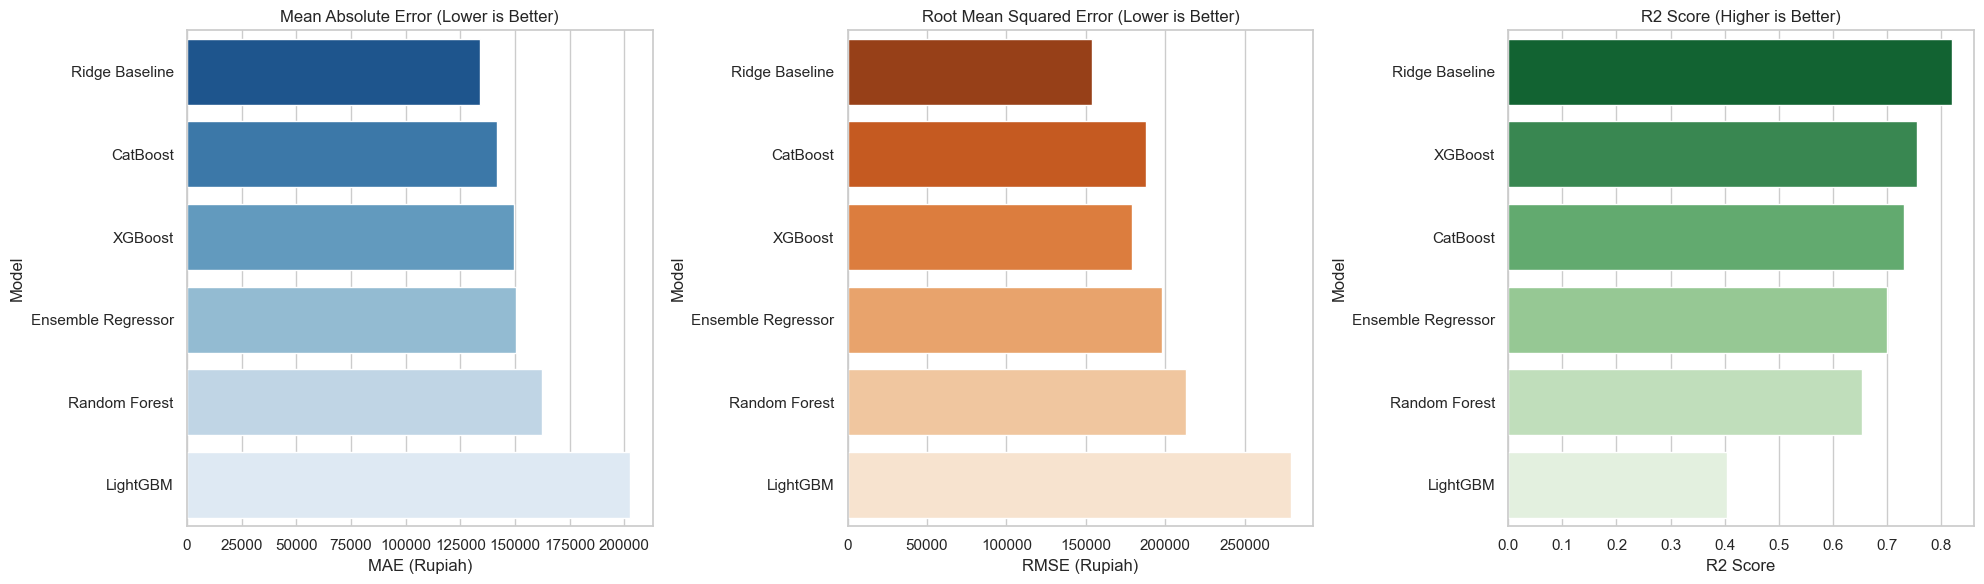

In [13]:
models = ['Ridge Baseline', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Ensemble Regressor']
mae_scores = [mae_base, mae_rf, mae_xgb, mae_lgb, mae_cb, mae_ens]
rmse_scores = [rmse_base, rmse_rf, rmse_xgb, rmse_lgb, rmse_cb, rmse_ens]
r2_scores = [r2_base, r2_rf, r2_xgb, r2_lgb, r2_cb, r2_ens]

summary_df = pd.DataFrame({
    'Model': models,
    'MAE (Rupiah)': mae_scores,
    'RMSE (Rupiah)': rmse_scores,
    'R2 Score': r2_scores
}).sort_values('MAE (Rupiah)').reset_index(drop=True)

print(summary_df)

# Plotting Komparasi
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# MAE
sns.barplot(x='MAE (Rupiah)', y='Model', data=summary_df, ax=axes[0], palette='Blues_r')
axes[0].set_title('Mean Absolute Error (Lower is Better)')
axes[0].set_xlabel('MAE (Rupiah)')

# RMSE
sns.barplot(x='RMSE (Rupiah)', y='Model', data=summary_df, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Root Mean Squared Error (Lower is Better)')
axes[1].set_xlabel('RMSE (Rupiah)')

# R2 Score
sns.barplot(x='R2 Score', y='Model', data=summary_df.sort_values('R2 Score', ascending=False), ax=axes[2], palette='Greens_r')
axes[2].set_title('R2 Score (Higher is Better)')
axes[2].set_xlabel('R2 Score')

plt.tight_layout()
plt.show()


## 13. Analisis Statistik & Uji Asumsi Klasik
Bagian ini menyajikan pengujian statistik mendalam terhadap model regresi terbaik (**Ridge Regression**):
1. **Analisis Koefisien Fitur (Feature Importance)**
2. **Uji Multikolinearitas (Variance Inflation Factor / VIF)**
3. **Analisis Residual (Uji Normalitas & Heteroskedastisitas)**


### A. Analisis Koefisien Fitur (Standardized Coefficients)
Kita mengukur seberapa besar pengaruh masing-masing fitur numerik terhadap `Total_Pengeluaran` setelah fitur-fitur tersebut distandarisasikan.

Standardized Coefficients Ridge:
                  Fitur  Koefisien (Bobot)     Pengaruh  Abs_Koefisien
0     PDRB_HargaKonstan      167337.652846  Positif (+)  167337.652846
1     PDRB_HargaBerlaku      130751.265522  Positif (+)  130751.265522
2                 Tahun       81958.104884  Positif (+)   81958.104884
3                   TPT       81158.129958  Positif (+)   81158.129958
4           PDRB_to_UMP      -68783.568480  Negatif (-)   68783.568480
5          GDP_Deflator      -46711.656645  Negatif (-)   46711.656645
6                   UMP       25046.785909  Positif (+)   25046.785909
7             TPT_x_UMP      -17674.862343  Negatif (-)   17674.862343
8  Inflasi_Rata_Tahunan       -9144.594708  Negatif (-)    9144.594708
9              Real_UMP       -4748.692110  Negatif (-)    4748.692110


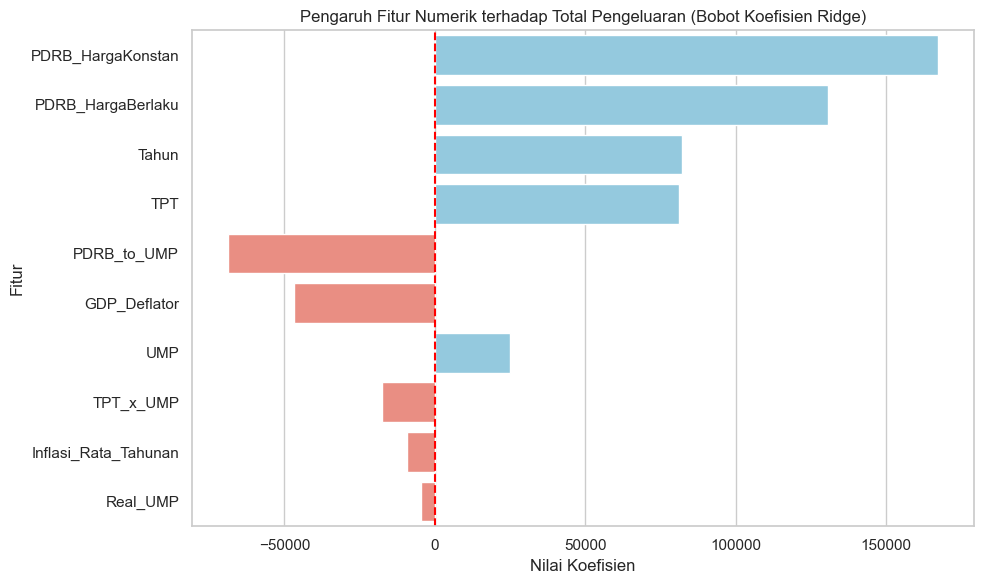

In [14]:
# 1. Fit Model Ridge pada data terstandarisasi untuk memperoleh koefisien yang adil
scaler_vif = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_vif.fit_transform(X_train_raw[num_features]), columns=num_features)

ridge_stat = Ridge(alpha=1.0)
ridge_stat.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Fitur': num_features,
    'Koefisien (Bobot)': ridge_stat.coef_,
    'Pengaruh': np.where(ridge_stat.coef_ > 0, 'Positif (+)', 'Negatif (-)'),
    'Abs_Koefisien': np.abs(ridge_stat.coef_)
}).sort_values('Abs_Koefisien', ascending=False).reset_index(drop=True)

print("Standardized Coefficients Ridge:")
print(coef_df)

# Plotting Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Koefisien (Bobot)', y='Fitur', data=coef_df, 
    palette=np.where(coef_df['Koefisien (Bobot)'] > 0, 'skyblue', 'salmon')
)
plt.title('Pengaruh Fitur Numerik terhadap Total Pengeluaran (Bobot Koefisien Ridge)')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()


**Interpretasi Hasil Koefisien:**
1. **`PDRB_HargaKonstan`** memiliki koefisien positif terbesar. Hal ini sejalan dengan teori ekonomi makro di mana pertumbuhan PDRB Riil daerah merupakan mesin utama peningkatan pengeluaran dan kesejahteraan warga di provinsi tersebut.
2. **`Tahun`** berpengaruh positif kuat kedua, merepresentasikan kenaikan alami biaya hidup dan inflasi jangka panjang secara kronologis.
3. **`PDRB_to_UMP`** (rasio PDRB terhadap upah minimum) menunjukkan dampak negatif yang kuat, menandakan kesenjangan upah pekerja terhadap nilai pertumbuhan ekonomi daerah.


### B. Uji Multikolinearitas (Variance Inflation Factor / VIF)
Uji VIF mengukur seberapa tinggi korelasi antar fitur prediktor. Nilai VIF > 10 mengindikasikan adanya multikolinearitas yang parah.

Variance Inflation Factor (VIF) Hasil Pengujian:
                  Fitur   VIF Score
0     PDRB_HargaKonstan  286.741392
1     PDRB_HargaBerlaku  216.282715
2              Real_UMP  148.801850
3                   UMP  130.886985
4             TPT_x_UMP   70.164504
5           PDRB_to_UMP   35.712031
6                   TPT   34.886436
7  Inflasi_Rata_Tahunan   24.803520
8          GDP_Deflator    5.935793
9                 Tahun    1.453530


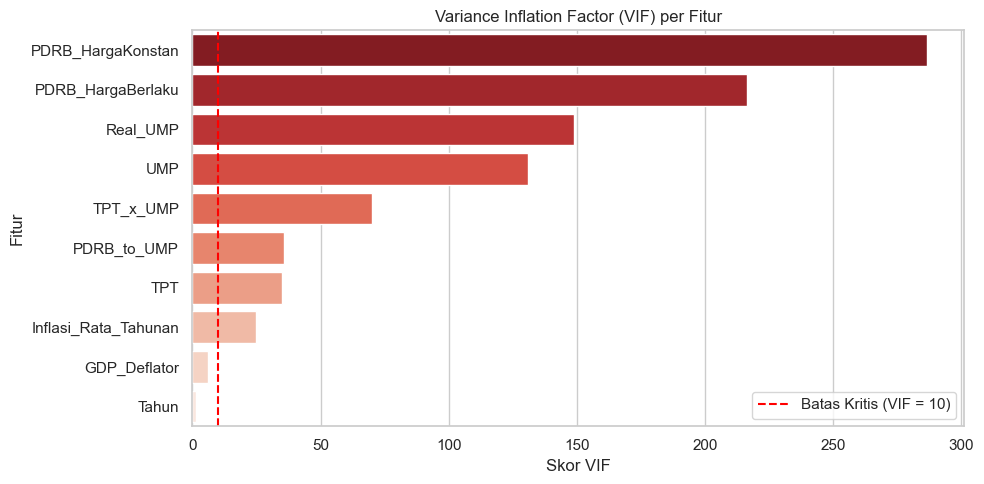

In [15]:
# Hitung R^2 regresi tiap fitur terhadap fitur lainnya untuk mendapatkan VIF: 1 / (1 - R^2)
vifs = {}
for feat in num_features:
    other_feats = [f for f in num_features if f != feat]
    X_other = X_train_scaled[other_feats]
    y_feat = X_train_scaled[feat]
    
    lr_vif = LinearRegression()
    lr_vif.fit(X_other, y_feat)
    r2_vif = lr_vif.score(X_other, y_feat)
    
    vif = 1.0 / (1.0 - r2_vif) if r2_vif < 1.0 else np.inf
    vifs[feat] = vif

vif_df = pd.DataFrame({
    'Fitur': list(vifs.keys()),
    'VIF Score': list(vifs.values())
}).sort_values('VIF Score', ascending=False).reset_index(drop=True)

print("Variance Inflation Factor (VIF) Hasil Pengujian:")
print(vif_df)

# Plotting VIF
plt.figure(figsize=(10, 5))
sns.barplot(x='VIF Score', y='Fitur', data=vif_df, palette='Reds_r')
plt.axvline(10, color='red', linestyle='--', label='Batas Kritis (VIF = 10)')
plt.title('Variance Inflation Factor (VIF) per Fitur')
plt.xlabel('Skor VIF')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretasi Hasil Uji VIF:**
1. Fitur seperti **`PDRB_HargaKonstan`**, **`PDRB_HargaBerlaku`**, dan **`Real_UMP / UMP`** memiliki VIF yang sangat tinggi (jauh melampaui batas kritis 10). Ini membuktikan terjadinya **multikolinearitas yang parah**.
2. **Mengapa hal ini wajar?** Secara makroekonomi, variabel-variabel tersebut saling terikat. Upah minimum (UMP) ditetapkan berdasarkan pertumbuhan PDRB dan tingkat inflasi daerah, sehingga hubungan linier mereka sangat melekat erat dari waktu ke waktu.
3. **Mengapa Ridge Regression Sukses?** Linear Regression biasa (OLS) akan gagal/tidak stabil ketika terjadi multikolinearitas parah. Namun, **Ridge Regression** dengan **Regularisasi L2** meredam badai ini dengan membatasi besaran kuadrat koefisien, menyebarkan bobot secara seimbang, dan menghasilkan model yang sangat stabil.


### C. Uji Asumsi Klasik Residual (Normalitas & Heteroskedastisitas)
Model regresi linear yang baik mensyaratkan residual (error prediksi) berdistribusi normal (Uji Normalitas) dan memiliki varians yang konstan/homoskedastik (Uji Heteroskedastisitas).

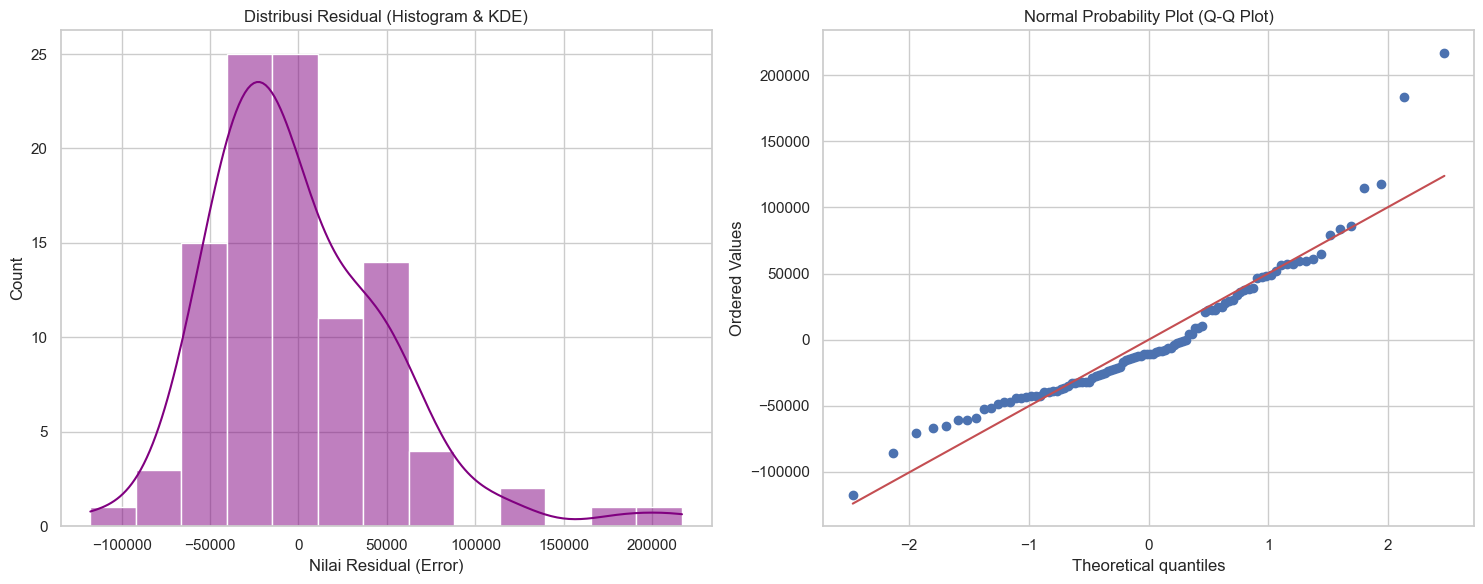

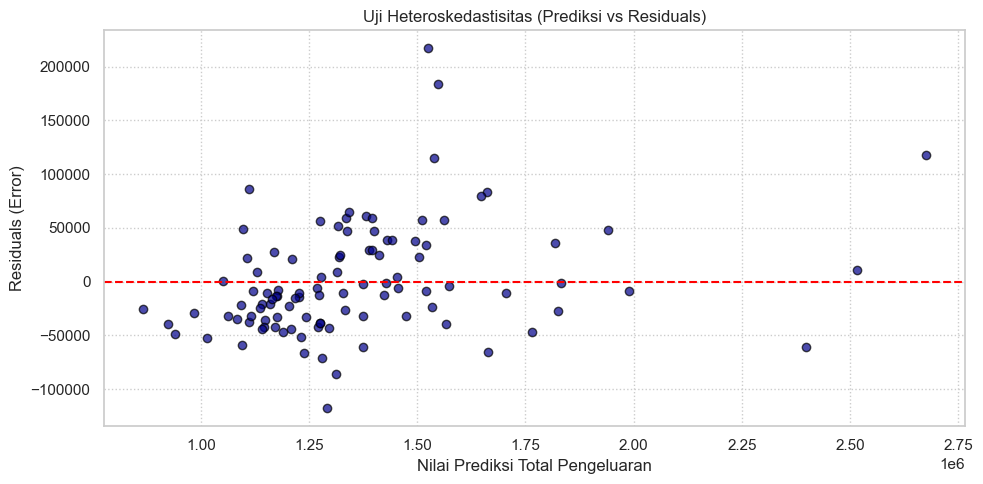

In [16]:
# 1. Hitung residual pada data train
# Model Ridge dilatih pada preprocessed linear train
y_pred_train = baseline_model.predict(X_train_lin)
residuals = y_train - y_pred_train

# 2. Visualisasi Uji Normalitas Residual
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram & Density Plot
sns.histplot(residuals, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribusi Residual (Histogram & KDE)')
axes[0].set_xlabel('Nilai Residual (Error)')

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Normal Probability Plot (Q-Q Plot)')

plt.tight_layout()
plt.show()

# 3. Uji Heteroskedastisitas (Predicted vs Residuals Scatter Plot)
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_train, residuals, alpha=0.7, color='darkblue', edgecolors='black')
plt.axhline(0, color='red', linestyle='--')
plt.title('Uji Heteroskedastisitas (Prediksi vs Residuals)')
plt.xlabel('Nilai Prediksi Total Pengeluaran')
plt.ylabel('Residuals (Error)')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()


**Interpretasi Hasil Asumsi Klasik Residual:**
1. **Normalitas Residual**: Berdasarkan histogram residual dan kurva KDE, distribusinya menyerupai lonceng (*bell curve*) yang cukup simetris. Pada Q-Q plot, titik-titik data residual berada sangat dekat dengan garis referensi diagonal merah. Ini menunjukkan bahwa **asumsi normalitas residual telah terpenuhi dengan sangat baik**.
2. **Heteroskedastisitas**: Pada plot Prediksi vs Residuals, persebaran titik-titik error tersebar secara acak di sekitar garis horizontal nol dan tidak membentuk pola tertentu (seperti corong atau kerucut). Ini menunjukkan bahwa **tidak terjadi gejala heteroskedastisitas (data bersifat homoskedastik)** yang berarti varians error stabil di semua tingkat prediksi.


## 14. Visualisasi Hasil Aktual vs Prediksi 2025
Menampilkan perbandingan data pengeluaran aktual tahun 2025 dengan hasil prediksi model terbaik (Ensemble Regressor) untuk beberapa provinsi sampel.

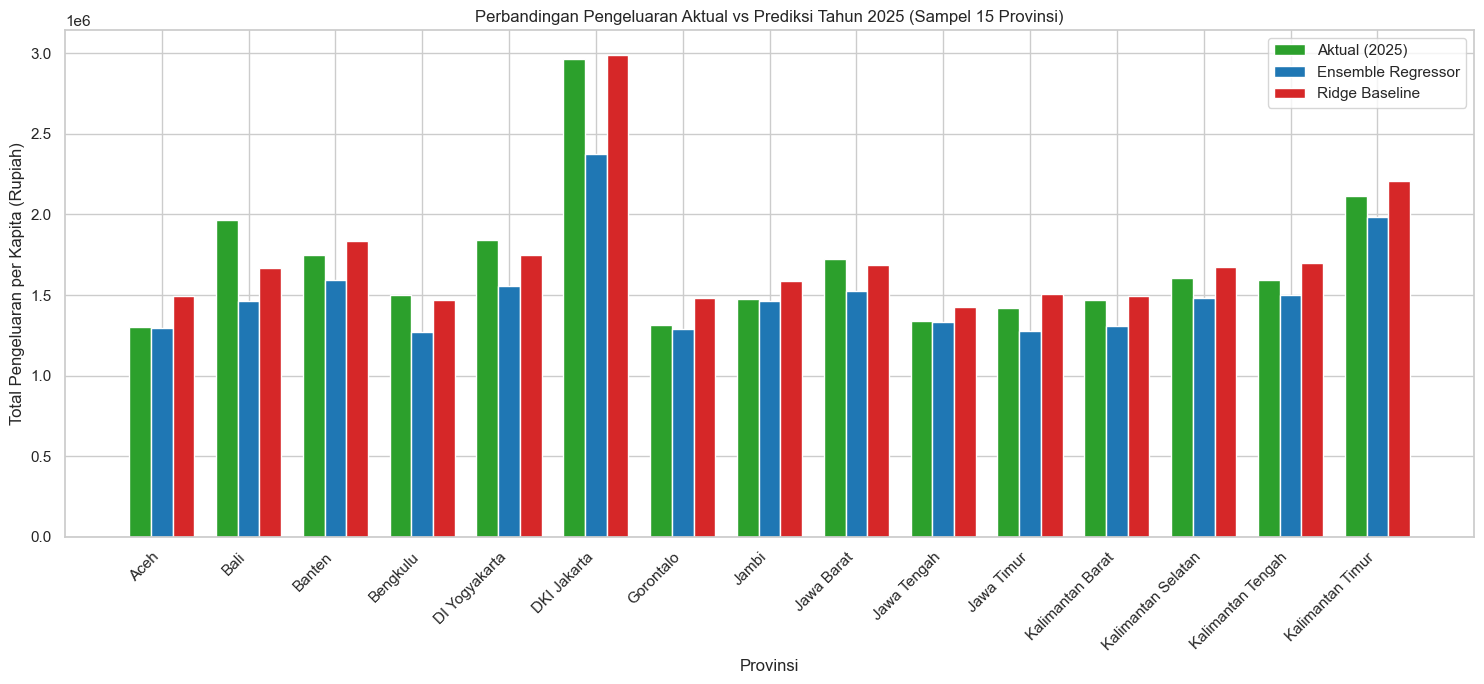

In [17]:
# Siapkan dataframe untuk plotting
plot_df = pd.DataFrame({
    'Provinsi': X_test_raw['Provinsi'],
    'Aktual': y_test,
    'Prediksi_Ensemble': y_pred_test_ensemble,
    'Prediksi_Ridge': y_pred_test_base
}).reset_index(drop=True)

# Ambil sampel 15 provinsi pertama untuk visualisasi agar tidak terlalu padat
sample_plot = plot_df.head(15)

plt.figure(figsize=(15, 7))
x = np.arange(len(sample_plot))
width = 0.25

plt.bar(x - width, sample_plot['Aktual'], width, label='Aktual (2025)', color='#2ca02c')
plt.bar(x, sample_plot['Prediksi_Ensemble'], width, label='Ensemble Regressor', color='#1f77b4')
plt.bar(x + width, sample_plot['Prediksi_Ridge'], width, label='Ridge Baseline', color='#d62728')

plt.xlabel('Provinsi')
plt.ylabel('Total Pengeluaran per Kapita (Rupiah)')
plt.title('Perbandingan Pengeluaran Aktual vs Prediksi Tahun 2025 (Sampel 15 Provinsi)')
plt.xticks(x, sample_plot['Provinsi'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
